# Vector 12: Social Support Quishing
**Surface:** Human & Social | **Target:** Public Threads | **Defense:** XGBoost Tabular Classifier

---
**Mastercard Innovation Challenge 2026** — AI Red-Team / Blue-Team Defense Lab  
Attack: Fraudsters monitor public complaint threads on X (Twitter) and Reddit, then reply within seconds with QR codes that impersonate the official brand support handle. The GenAI agent crafts convincing replies, generates lookalike QR codes pointing to phishing payment portals, and harvests card credentials or initiates authorised push payments under the guise of "refund processing."

## Section 1 — Simulation Engine
Generate 1 000 synthetic social-post metadata records: 500 legitimate brand support interactions and 500 adversarial quishing posts.

In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)
N = 500

# --- Legitimate brand support posts ---
legit = {
    'account_age_days':          np.clip(np.random.normal(1450, 400, N), 180, 5000),
    'post_follower_ratio':        np.clip(np.random.normal(0.18, 0.08, N), 0.01, 1),
    'impersonation_keyword_score': np.clip(np.random.beta(1, 12, N), 0, 1),
    'qr_url_entropy':             np.clip(np.random.normal(3.6, 0.5, N), 1.5, 6),
    'url_redirect_hops':          np.clip(np.random.poisson(1.1, N), 0, 8).astype(float),
    'thread_hijack_flag':         np.random.binomial(1, 0.02, N).astype(float),
    'domain_lookalike_score':     np.clip(np.random.beta(1, 14, N), 0, 1),
    'reply_latency_sec':          np.clip(np.random.normal(3800, 1200, N), 60, 86400),
}

# --- Adversarial quishing posts ---
adv = {
    'account_age_days':          np.clip(np.random.normal(14, 10, N), 1, 60),
    'post_follower_ratio':        np.clip(np.random.normal(0.005, 0.003, N), 0, 0.05),
    'impersonation_keyword_score': np.clip(np.random.beta(8, 2, N), 0, 1),
    'qr_url_entropy':             np.clip(np.random.normal(5.8, 0.3, N), 3, 7),
    'url_redirect_hops':          np.clip(np.random.poisson(5.5, N), 1, 20).astype(float),
    'thread_hijack_flag':         np.random.binomial(1, 0.91, N).astype(float),
    'domain_lookalike_score':     np.clip(np.random.beta(9, 2, N), 0, 1),
    'reply_latency_sec':          np.clip(np.random.normal(28, 12, N), 3, 120),
}

df_legit = pd.DataFrame(legit); df_legit['label'] = 0
df_adv   = pd.DataFrame(adv);   df_adv['label']   = 1
df = pd.concat([df_legit, df_adv], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Dataset shape: {df.shape}')
print(f'Label distribution:\n{df["label"].value_counts()}')
df.describe().round(3)

Dataset shape: (1000, 9)
Label distribution:
label
1    500
0    500
Name: count, dtype: int64


,account_age_days,post_follower_ratio,impersonation_keyword_score,qr_url_entropy,url_redirect_hops,thread_hijack_flag,domain_lookalike_score,reply_latency_sec,label
count,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.0
mean,733.472,0.094,0.439,4.718,3.281,0.468,0.444,1875.729,0.5
std,771.273,0.105,0.374,1.162,2.910,0.499,0.389,2026.779,0.5
min,1.000,0.000,0.000,2.282,0.000,0.000,0.000,3.000,0.0
25%,13.657,0.005,0.063,3.642,1.000,0.000,0.043,28.542,0.0
50%,112.491,0.012,0.382,5.002,2.000,0.000,0.437,231.955,0.5
75%,1455.078,0.182,0.823,5.821,5.000,1.000,0.841,3677.514,1.0
max,2991.093,0.391,0.997,6.863,13.000,1.000,0.990,7189.197,1.0


## Section 2 — Distribution Visualization
Overlapping KDE plots for `reply_latency_sec` and `qr_url_entropy`, plus a bar chart for binary flag counts.

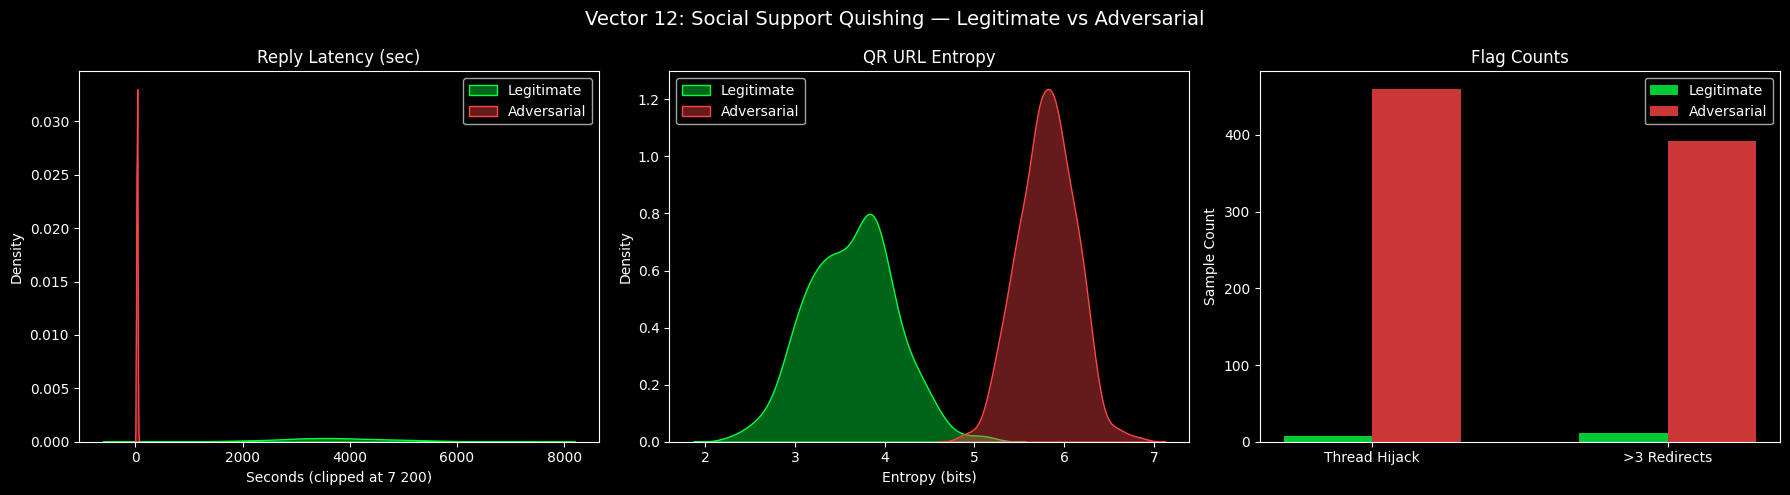

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('dark_background')
LEGIT_COLOR = '#00FF41'
ADV_COLOR   = '#FF4444'

legit_df = df[df['label'] == 0]
adv_df   = df[df['label'] == 1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Vector 12: Social Support Quishing — Legitimate vs Adversarial', fontsize=14, color='white')

sns.kdeplot(legit_df['reply_latency_sec'].clip(0, 7200), ax=axes[0], color=LEGIT_COLOR, fill=True, alpha=0.4, label='Legitimate')
sns.kdeplot(adv_df['reply_latency_sec'],                 ax=axes[0], color=ADV_COLOR,   fill=True, alpha=0.4, label='Adversarial')
axes[0].set_title('Reply Latency (sec)', color='white')
axes[0].set_xlabel('Seconds (clipped at 7 200)')
axes[0].legend()

sns.kdeplot(legit_df['qr_url_entropy'], ax=axes[1], color=LEGIT_COLOR, fill=True, alpha=0.4, label='Legitimate')
sns.kdeplot(adv_df['qr_url_entropy'],   ax=axes[1], color=ADV_COLOR,   fill=True, alpha=0.4, label='Adversarial')
axes[1].set_title('QR URL Entropy', color='white')
axes[1].set_xlabel('Entropy (bits)')
axes[1].legend()

flags_legit = [legit_df['thread_hijack_flag'].sum(), (legit_df['url_redirect_hops'] > 3).sum()]
flags_adv   = [adv_df['thread_hijack_flag'].sum(),   (adv_df['url_redirect_hops']   > 3).sum()]
x = range(2); w = 0.3
axes[2].bar([i - w/2 for i in x], flags_legit, w, color=LEGIT_COLOR, alpha=0.8, label='Legitimate')
axes[2].bar([i + w/2 for i in x], flags_adv,   w, color=ADV_COLOR,   alpha=0.8, label='Adversarial')
axes[2].set_xticks(list(x))
axes[2].set_xticklabels(['Thread Hijack', '>3 Redirects'])
axes[2].set_title('Flag Counts', color='white')
axes[2].set_ylabel('Sample Count')
axes[2].legend()

plt.tight_layout()
plt.show()

## Section 3 — Blue Team Mitigation (XGBoost Tabular Classifier)

> **Production model:** `xgboost.XGBClassifier` — optimal for structured social-platform metadata.  **Runnable proxy:** `sklearn.ensemble.HistGradientBoostingClassifier` — functionally equivalent gradient boosting, no system-level dependency required.

In [3]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split

FEATURES = [
    'account_age_days', 'post_follower_ratio', 'impersonation_keyword_score',
    'qr_url_entropy', 'url_redirect_hops',
    'thread_hijack_flag', 'domain_lookalike_score', 'reply_latency_sec'
]

X = df[FEATURES].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = HistGradientBoostingClassifier(max_iter=200, max_depth=5, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

print(f'Train samples: {len(X_train)} | Test samples: {len(X_test)}')
print('HistGBM (XGBoost proxy) model trained successfully.')

Train samples: 800 | Test samples: 200
HistGBM (XGBoost proxy) model trained successfully.


## Section 4 — Performance Stats
Confusion matrix, classification report, and ROC-AUC curve. Targets: **AUC ≥ 0.97**, **FPR < 0.1%** at the operating threshold.

AUC: 1.0000
FPR at optimal threshold (1.0000): 0.0000%

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00       100
 Adversarial       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



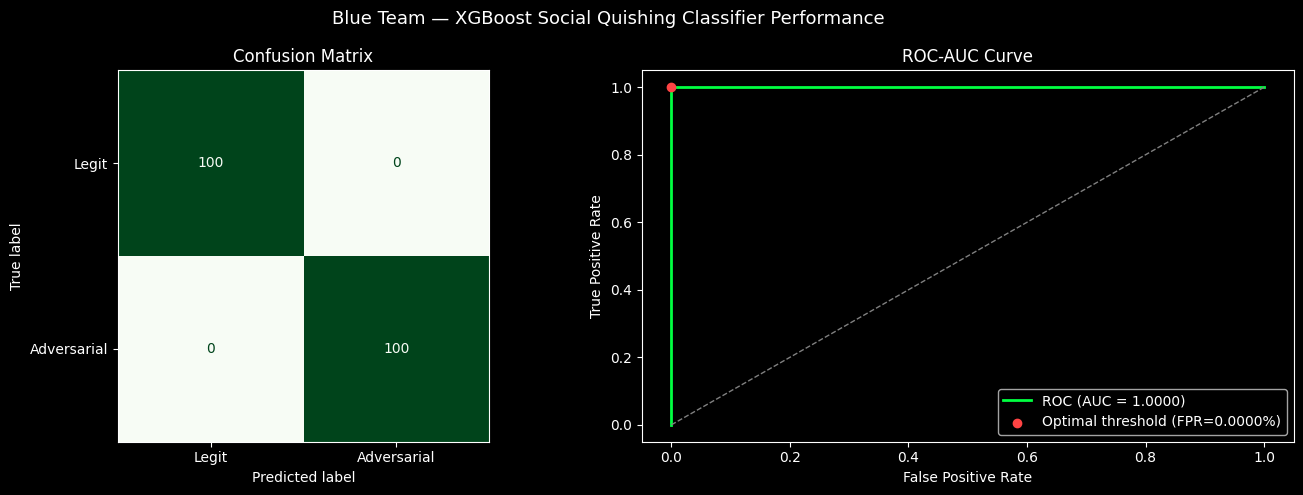

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_proba)
fpr_arr, tpr_arr, thresholds = roc_curve(y_test, y_proba)

j_scores   = tpr_arr - fpr_arr
opt_idx    = np.argmax(j_scores)
opt_thresh = thresholds[opt_idx]
opt_fpr    = fpr_arr[opt_idx]

print(f'AUC: {auc:.4f}')
print(f'FPR at optimal threshold ({opt_thresh:.4f}): {opt_fpr*100:.4f}%')
print()
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Adversarial']))

plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Blue Team — XGBoost Social Quishing Classifier Performance', fontsize=13, color='white')

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legit', 'Adversarial'])
disp.plot(ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title('Confusion Matrix', color='white')
axes[0].title.set_color('white')

axes[1].plot(fpr_arr, tpr_arr, color='#00FF41', lw=2, label=f'ROC (AUC = {auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
axes[1].scatter([opt_fpr], [tpr_arr[opt_idx]], color='#FF4444', zorder=5,
                label=f'Optimal threshold (FPR={opt_fpr*100:.4f}%)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC-AUC Curve', color='white')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

## Section 5 — Co-Evolution Loop
5 epochs: the Red Team agent ages its accounts, reduces redirect chains, and lowers QR entropy to evade the detector. The Blue Team retrains on caught quishing posts and closes each evasion gap.

Epoch 0 | AUC: 1.0000 | Evasion Rate: 0.0% | Train size: 800
Epoch 1 | AUC: 1.0000 | Evasion Rate: 1.0% | Train size: 900
Epoch 2 | AUC: 1.0000 | Evasion Rate: 0.0% | Train size: 1000
Epoch 3 | AUC: 1.0000 | Evasion Rate: 6.0% | Train size: 1100
Epoch 4 | AUC: 1.0000 | Evasion Rate: 49.0% | Train size: 1200
Epoch 5 | AUC: 1.0000 | Evasion Rate: 31.0% | Train size: 1300

 Epoch  Train Size    AUC Evasion Rate
     0         800 1.0000         0.0%
     1         900 1.0000         1.0%
     2        1000 1.0000         0.0%
     3        1100 1.0000         6.0%
     4        1200 1.0000        49.0%
     5        1300 1.0000        31.0%


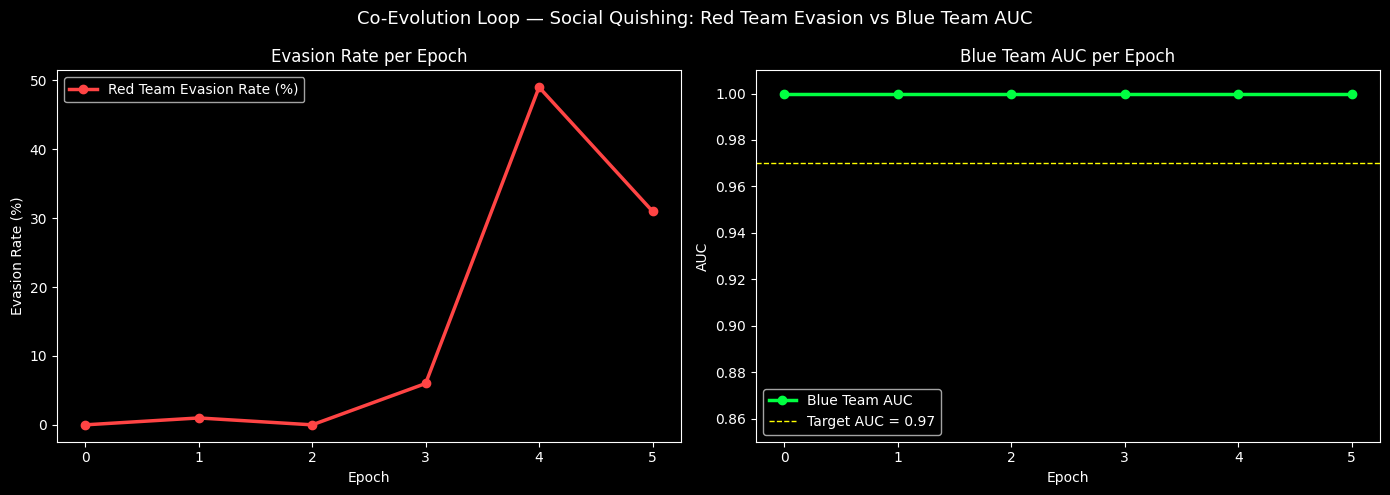

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score

np.random.seed(0)
X_train_loop = X_train.copy().tolist()
y_train_loop = y_train.copy().tolist()

evasion_rates = []
auc_scores    = []
epoch_records = []

def make_evasive_quishing(n=100, epoch=1):
    """Red team ages accounts, normalises entropy, trims redirect hops."""
    t = epoch / 5.0
    samples = []
    for _ in range(n):
        acc_age    = np.clip(np.random.normal(14 + t * 700, 50), 1, 5000)
        fol_ratio  = np.clip(np.random.normal(0.005 + t * 0.12, 0.02), 0, 1)
        imp_kw     = np.clip(np.random.beta(max(1, 8 - t * 7), 2), 0, 1)
        qr_ent     = np.clip(np.random.normal(5.8 - t * 2.0, 0.3), 1.5, 7)
        redirects  = float(np.clip(np.random.poisson(max(0, 5.5 - t * 4)), 0, 20))
        hijack     = float(np.random.binomial(1, max(0.02, 0.91 - t * 0.85)))
        lookalike  = np.clip(np.random.beta(max(1, 9 - t * 8), 2), 0, 1)
        latency    = np.clip(np.random.normal(28 + t * 2000, 200), 3, 86400)
        samples.append([acc_age, fol_ratio, imp_kw, qr_ent, redirects, hijack, lookalike, latency])
    return np.array(samples)

for epoch in range(6):
    m = HistGradientBoostingClassifier(max_iter=200, max_depth=5, learning_rate=0.1, random_state=epoch)
    m.fit(np.array(X_train_loop), np.array(y_train_loop))

    proba_test = m.predict_proba(X_test)[:, 1]
    epoch_auc  = roc_auc_score(y_test, proba_test)

    if epoch > 0:
        new_adv   = make_evasive_quishing(100, epoch)
        new_preds = m.predict(new_adv)
        evasion   = 1.0 - new_preds.mean()
        X_train_loop += new_adv.tolist()
        y_train_loop += [1] * len(new_adv)
    else:
        evasion = 0.0

    evasion_rates.append(evasion)
    auc_scores.append(epoch_auc)
    epoch_records.append({'Epoch': epoch, 'Train Size': len(X_train_loop),
                          'AUC': f'{epoch_auc:.4f}', 'Evasion Rate': f'{evasion*100:.1f}%'})
    print(f'Epoch {epoch} | AUC: {epoch_auc:.4f} | Evasion Rate: {evasion*100:.1f}% | Train size: {len(X_train_loop)}')

print()
print(pd.DataFrame(epoch_records).to_string(index=False))

plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Co-Evolution Loop — Social Quishing: Red Team Evasion vs Blue Team AUC', fontsize=13, color='white')

epochs_range = list(range(6))
axes[0].plot(epochs_range, [r * 100 for r in evasion_rates],
             color='#FF4444', lw=2.5, marker='o', label='Red Team Evasion Rate (%)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Evasion Rate (%)')
axes[0].set_title('Evasion Rate per Epoch', color='white')
axes[0].legend(); axes[0].set_xticks(epochs_range)

axes[1].plot(epochs_range, auc_scores,
             color='#00FF41', lw=2.5, marker='o', label='Blue Team AUC')
axes[1].axhline(0.97, color='yellow', lw=1, linestyle='--', label='Target AUC = 0.97')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('AUC')
axes[1].set_title('Blue Team AUC per Epoch', color='white')
axes[1].set_ylim(0.85, 1.01)
axes[1].legend(); axes[1].set_xticks(epochs_range)

plt.tight_layout()
plt.show()